<a href="https://colab.research.google.com/github/vencov/FAV_course/blob/main/TutIHC03/EX_IHCsimple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A simple IHC / auditory-nerve model (Dau / Jepsen type)

This notebook is a Python port of a MATLAB implementation of a simple **phenomenological** inner hair cell (IHC) and auditory nerve (AN) model, following Dau et al. (1996) and Jepsen et al. (2008).

The input is a signal representing **basilar membrane (BM) displacement at one point**. The model consists of four stages:

1. **Half-wave rectifier**: only displacement in one direction opens the MET channels
2. **Low-pass filter (1 kHz, 1st order)**: membrane low-pass behaviour, giving the "membrane potential"
3. **Adaptation feedback loops**: a chain of 5 nonlinear RC loops producing compression and adaptation, i.e. the transformation of receptor potential into a quantity related to the AN firing probability
4. **Low-pass filter (20 ms)**: temporal smoothing of the output

**Learning goals**

- see how each stage shapes the signal
- understand how the adaptation loops produce an onset response followed by decay to a steady state
- explore how the model responds to different levels and frequencies

**Note for comparison with conductance-based models:** unlike Hodgkin-Huxley-type IHC models, there are no ion channels or reversal potentials here. The model is a signal-processing cascade, which makes it fast and easy to use as a front end of larger auditory models.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

plt.rcParams.update({"figure.figsize": (9, 7), "axes.grid": True, "grid.alpha": 0.3})

## 1. Stage 1-2: rectifier and 1 kHz low-pass filter

The input is half-wave rectified (negative values set to zero), then filtered by a 1st-order Butterworth low-pass filter with a 1 kHz cutoff. The result is called the "membrane potential" `V`.

Two things happen here:

- **Rectification** creates a DC component (the mean of a half-wave rectified sine of amplitude A is A/pi) and harmonics.
- **Low-pass filtering** attenuates the AC component at high frequencies, which models the loss of phase locking above a few kHz. A 1st-order filter is a very crude description of the real IHC membrane behaviour.

## 2. Stage 3: adaptation feedback loops

This is the core of the model. The input passes through a chain of `N = 5` loops. In each loop the input is **divided** by a low-pass filtered (RC) version of that loop's own output:

$$
y_k[n] = \frac{x_k[n]}{s_k[n-1]}, \qquad s_k[n] = a_k\, s_k[n-1] + (1-a_k)\, y_k[n], \qquad a_k = e^{-1/(\tau_k f_s)}
$$

with $x_{k+1} = y_k$. Consequences:

- At a **sudden onset**, the state $s_k$ is still small, so the output is large (overshoot).
- As the state catches up, the output **decays**, which is adaptation.
- In the steady state, the output of each loop becomes roughly the square root of its input, so a chain of 5 loops gives strong compression (close to logarithmic for a large input range).
- Time constants range from 5 ms to 500 ms, giving both fast and slow adaptation.

Additional parameters:

| Parameter | Meaning |
|---|---|
| `minVal` | minimum input value, which models the absolute threshold |
| `C` | limits the onset overshoot (modification by Muenkner, 1993) |
| `ScaleConst` | output scaling constant |

In [1]:
def rect_lp(x, fs, cutoff=1e3):
    # Half-wave rectification followed by a 1st-order Butterworth low-pass filter
    x = np.asarray(x, dtype=float).copy()
    x[x < 0] = 0.0
    b, a = butter(1, cutoff / (fs / 2))
    return lfilter(b, a, x)

def adaptloop(fs, x, tau, min_val, C, scale_const):
    # Adaptation feedback loops (Dau et al. 1996; Jepsen et al. 2008).
    # Transforms membrane potential into a quantity related to AN firing probability.
    tau = np.asarray(tau, dtype=float)
    n_loops = len(tau)

    a = np.exp(-1.0 / (tau * fs))
    b = 1.0 - a

    # Initial states (steady state for input = min_val)
    state = min_val ** (0.5 ** np.arange(1, n_loops + 1))

    corr = state[-1]
    mult = scale_const / (1.0 - corr)

    out = np.zeros_like(x, dtype=float)
    for i, xi in enumerate(x):
        tmp = xi if xi >= min_val else min_val   # absolute threshold
        for k in range(n_loops):
            tmp = tmp / state[k]
            if tmp > 1:                          # limit overshoot
                tmp = C * (2.0 / (1.0 + np.exp(-2.0 * (tmp - 1.0) / C)) - 1.0) + 1.0
            state[k] = a[k] * state[k] + b[k] * tmp
        out[i] = (tmp - corr) * mult
    return out

## 3. Stimulus

A pure tone representing BM displacement at one place along the cochlea.

- frequency 1 kHz, amplitude $10^{-8}$ (arbitrary displacement units; the absolute threshold `minVal = 1e-9` is defined in the same units)
- duration 100 ms, with 5 ms raised-cosine onset and offset ramps
- 20 ms of silence before and 80 ms after the tone

In [3]:
def make_tone(freq=1000.0, amp=1e-8, fs=40e3, t_dur=100e-3, r_dur=5e-3,
              pre_sil=20e-3, post_sil=80e-3):
    # Pure tone with raised-cosine ramps and silence before/after
    n_tone = int(round(t_dur * fs)) + 1
    tx = np.arange(n_tone) / fs
    sig = amp * np.sin(2 * np.pi * freq * tx)

    n_ramp = int(round(r_dur * fs)) + 1
    x = np.pi * (np.arange(n_ramp) / fs) / r_dur
    ramp_up = (1 + np.cos(x + np.pi)) / 2
    ramp_down = ramp_up[::-1]
    whole = np.concatenate([ramp_up, np.ones(n_tone - 2 * n_ramp), ramp_down])

    sig = np.concatenate([np.zeros(int(round(pre_sil * fs))),
                          sig * whole,
                          np.zeros(int(round(post_sil * fs)))])
    t = np.arange(len(sig)) / fs
    return t, sig

fs = 40e3
t, sig_in = make_tone(freq=1000, amp=1e-8, fs=fs)
print(f"{len(sig_in)} samples, {t[-1]*1e3:.1f} ms")

8001 samples, 200.0 ms


## 4. Run the full model

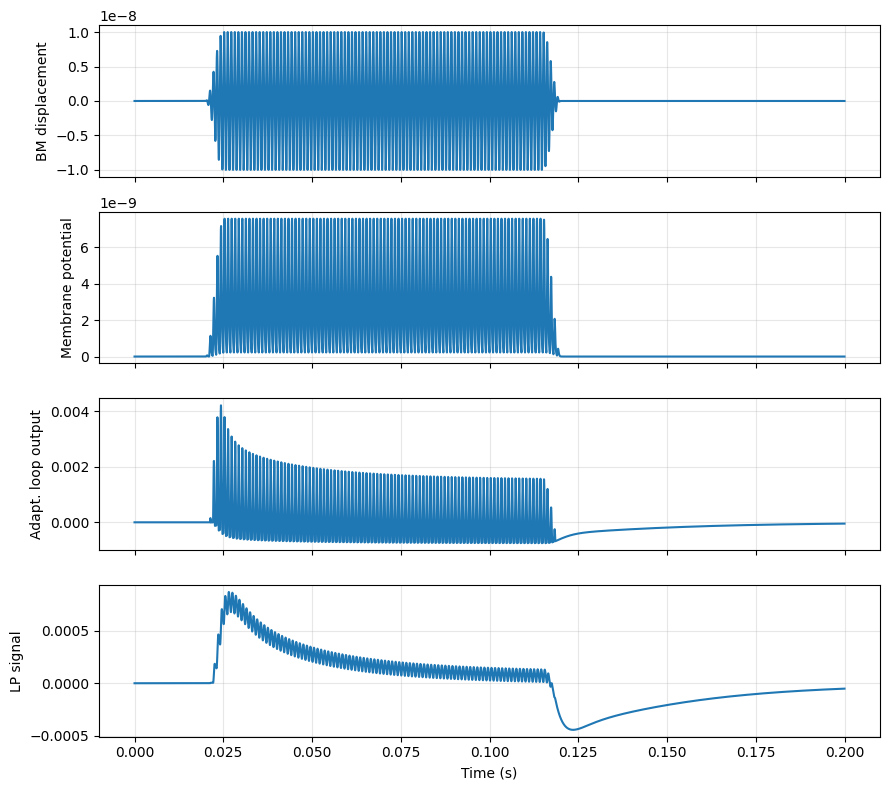

In [4]:
def ihc_an_model(sig_in, fs, tau=(0.005, 0.050, 0.129, 0.253, 0.5),
                 min_val=1e-9, C=10, scale_const=1e-3, tau_lp=20e-3):
    # Full model: rectifier + LP -> adaptation loops -> LP (tau_lp).
    # Returns membrane potential V, adaptation-loop output, and the final smoothed signal.
    V = rect_lp(sig_in, fs)
    out_al = adaptloop(fs, V, tau, min_val, C, scale_const)

    # Same cutoff definition as the original MATLAB code: fc = 1/tau_lp (= 50 Hz)
    b_lp, a_lp = butter(1, (1.0 / tau_lp) / (fs / 2))
    an_prob = lfilter(b_lp, a_lp, out_al)
    return V, out_al, an_prob

V, out_al, an_prob = ihc_an_model(sig_in, fs)

fig, ax = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
ax[0].plot(t, sig_in);  ax[0].set_ylabel("BM displacement")
ax[1].plot(t, V);       ax[1].set_ylabel("Membrane potential")
ax[2].plot(t, out_al);  ax[2].set_ylabel("Adapt. loop output")
ax[3].plot(t, an_prob); ax[3].set_ylabel("LP signal")
ax[3].set_xlabel("Time (s)")
plt.tight_layout(); plt.show()

### What to look at

- **Membrane potential (2nd panel):** a positive-only signal with a DC offset. A 1 kHz tone lies exactly at the 1 kHz cutoff of the 1st-order filter (about 3 dB attenuation), so a large 1 kHz ripple remains.
- **Adaptation loop output (3rd panel):** a strong onset peak followed by decay towards a steady state. After the tone ends, the output drops **below** its resting value, which is a recovery from adaptation. The 1 kHz fine structure is visible in the output because the loops respond to fast fluctuations.
- **Final LP signal (4th panel):** the fine structure is strongly reduced and the envelope dominates, with a smoothed onset peak and an undershoot after offset. A small ripple remains because the cutoff is 1/tau = 50 Hz (not 1/(2 pi tau) = 8 Hz), as in the original MATLAB code.

## 5. Zoom on the fine structure

The following plot zooms on a few milliseconds of the tone to show rectification and filtering.

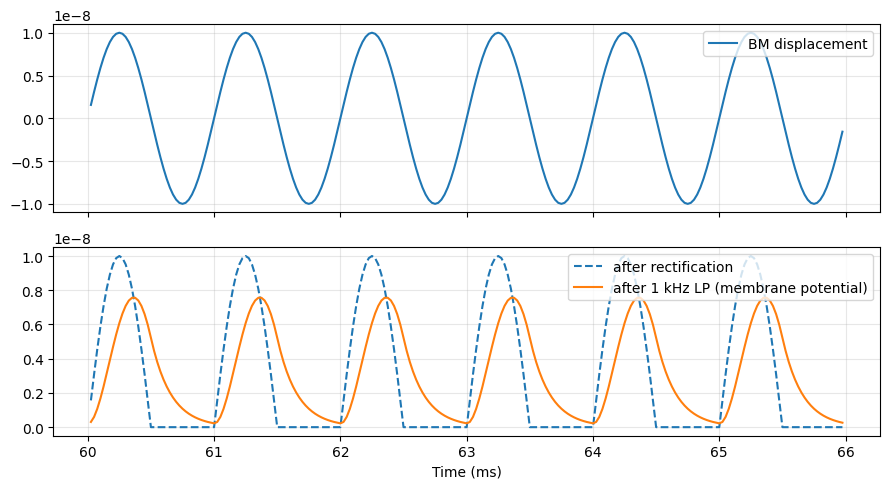

In [ ]:
sel = (t > 0.060) & (t < 0.066)
fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax[0].plot(t[sel]*1e3, sig_in[sel], label="BM displacement")
ax[0].legend(loc="upper right")
ax[1].plot(t[sel]*1e3, np.maximum(sig_in[sel], 0), "--", label="after rectification")
ax[1].plot(t[sel]*1e3, V[sel], label="after 1 kHz LP (membrane potential)")
ax[1].legend(loc="upper right"); ax[1].set_xlabel("Time (ms)")
plt.tight_layout(); plt.show()

## 6. Effect of stimulus level

Because of the adaptation loops, the model is **strongly compressive**: a 20 dB increase in input level does not produce a 20 dB increase in output. Let us compare the onset peak and the steady-state value for several levels.

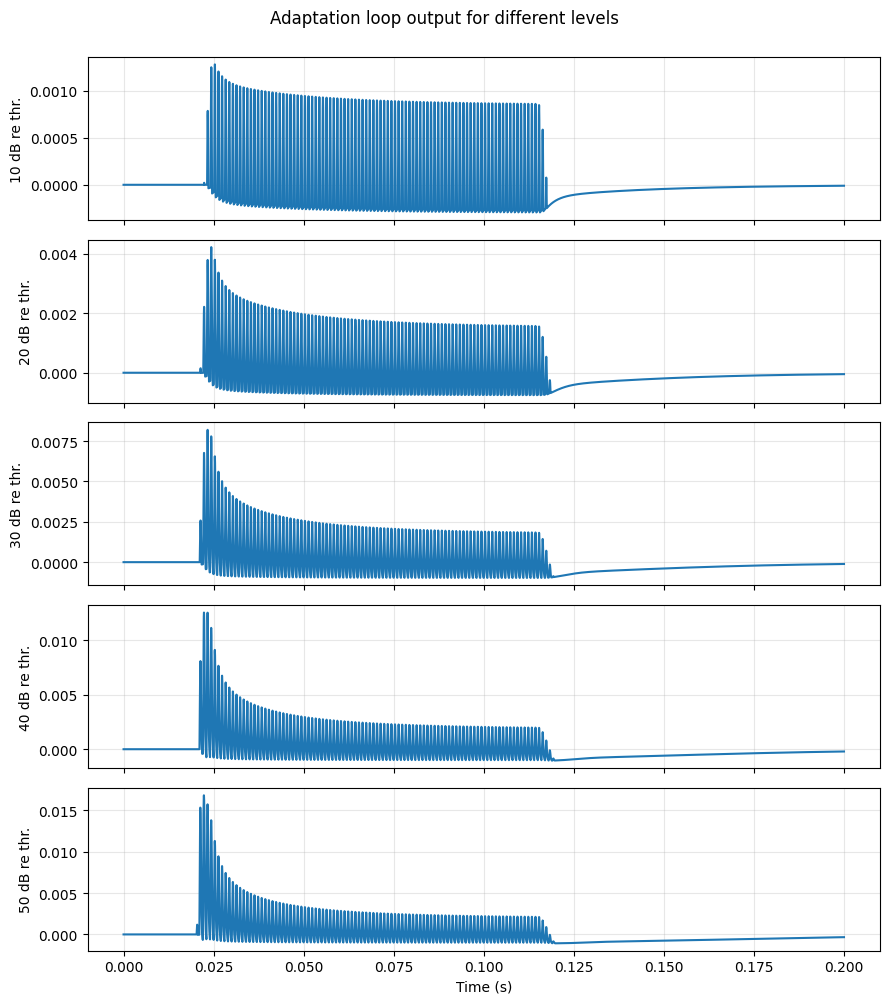

In [ ]:
levels_db = [10, 20, 30, 40, 50]      # relative to 1e-9 (the absolute threshold)
amps = 1e-9 * 10 ** (np.array(levels_db) / 20)

fig, ax = plt.subplots(len(amps), 1, figsize=(9, 10), sharex=True)
onset, steady = [], []
for a_, axi, L in zip(amps, ax, levels_db):
    _, s = make_tone(freq=1000, amp=a_, fs=fs)
    _, out, _ = ihc_an_model(s, fs)
    axi.plot(t, out)
    axi.set_ylabel(f"{L} dB re thr.")
    onset.append(out[(t > 0.02) & (t < 0.07)].max())
    steady.append(out[(t > 0.090) & (t < 0.110)].mean())   # 20 whole cycles, mid-tone
ax[-1].set_xlabel("Time (s)")
plt.suptitle("Adaptation loop output for different levels", y=1.0)
plt.tight_layout(); plt.show()

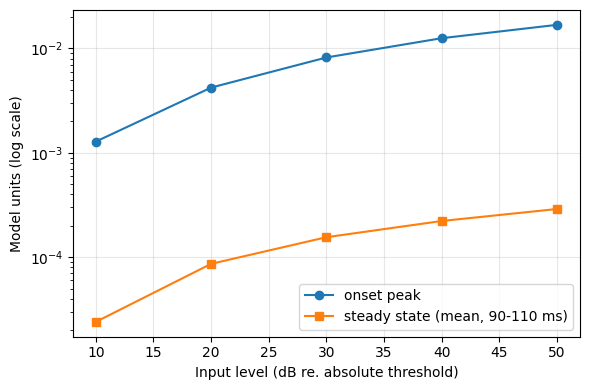

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(levels_db, onset, "o-", label="onset peak")
ax.semilogy(levels_db, steady, "s-", label="steady state (mean, 90-110 ms)")
ax.set_xlabel("Input level (dB re. absolute threshold)")
ax.set_ylabel("Model units (log scale)")
ax.legend(); plt.tight_layout(); plt.show()

**Questions for students**

- How does the ratio of onset peak to steady state change with level? (Hint: the overshoot limiter `C`.)
- The steady-state curve is compressive. Estimate its slope in dB/dB between 10 and 50 dB and compare it with 1:1.
- Inputs below the absolute threshold (`minVal`) produce no response. Try levels of -10 and 0 dB to see why.

## 7. Effect of stimulus frequency

The rectifier + 1 kHz low-pass combination means that the **AC component** of the membrane potential decreases as frequency increases, while the DC component stays the same. This is a simple picture of why phase locking is lost at high frequencies.

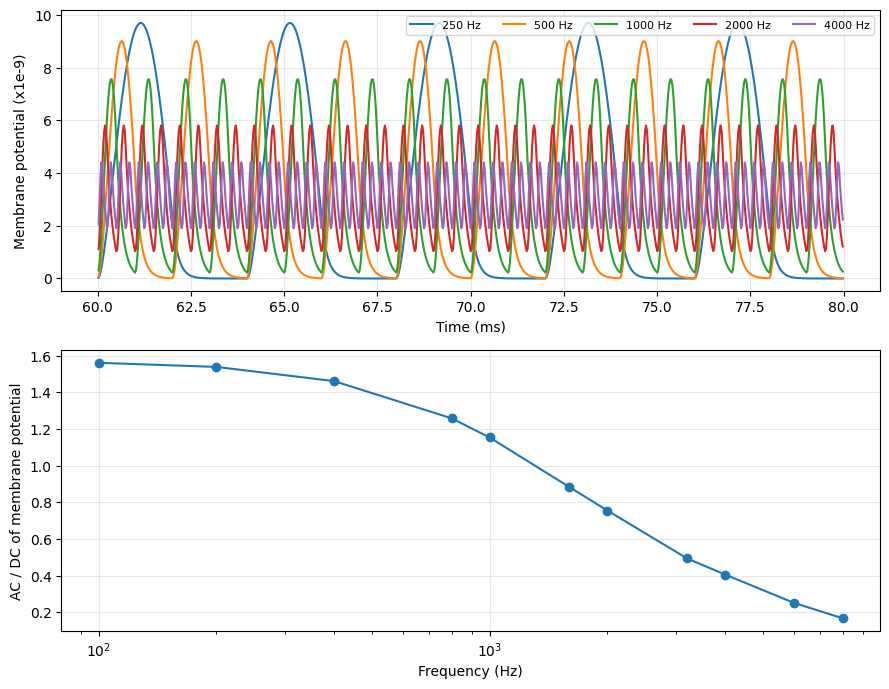

In [ ]:
freqs = [250, 500, 1000, 2000, 4000]
fig, ax = plt.subplots(2, 1, figsize=(9, 7))
for f in freqs:
    _, s = make_tone(freq=f, amp=1e-8, fs=fs)
    Vf, _, _ = ihc_an_model(s, fs)
    mid = (t > 0.06) & (t < 0.08)
    ax[0].plot(t[mid]*1e3, Vf[mid]*1e9, label=f"{f} Hz")
ax[0].set_xlabel("Time (ms)"); ax[0].set_ylabel("Membrane potential (x1e-9)")
ax[0].legend(ncol=5, fontsize=8)

# AC/DC ratio of membrane potential over frequency
fgrid = np.array([100, 200, 400, 800, 1000, 1600, 2000, 3200, 4000, 6000, 8000])
ratio = []
for f in fgrid:
    _, s = make_tone(freq=f, amp=1e-8, fs=fs)
    Vf = rect_lp(s, fs)
    seg = Vf[(t > 0.06) & (t < 0.09)]
    ratio.append((seg.max() - seg.min()) / 2 / seg.mean())
ax[1].semilogx(fgrid, ratio, "o-")
ax[1].set_xlabel("Frequency (Hz)"); ax[1].set_ylabel("AC / DC of membrane potential")
plt.tight_layout(); plt.show()

## 8. Summary and discussion

- The model has **very few parameters** and runs on any signal, so it is practical as a front end for larger auditory models (e.g. combined with a modulation filterbank, as in Jepsen et al. 2008).
- It reproduces **onset/offset enhancement, adaptation, and compression**, but it is **not** a biophysical model: there are no ion channels, no Ca$^{2+}$ dynamics, and no synapse.
- The rectifier + 1 kHz low-pass mimics the **receptor potential** of an IHC; the adaptation loops stand in for the **synapse and AN adaptation**.


**References**

- Dau, T., Puschel, D., Kohlrausch, A. (1996). A quantitative model of the "effective" signal processing in the auditory system. I. Model structure. *J. Acoust. Soc. Am.* 99, 3615-3622.
- Jepsen, M. L., Ewert, S. D., Dau, T. (2008). A computational model of human auditory signal processing and perception. *J. Acoust. Soc. Am.* 124, 422-438.
- Muenkner, S. (1993). Introduction of a feedback loop to the model of the auditory periphery (overshoot limiter). *Doctoral thesis, Univ. Oldenburg*.
